## 0. Setup

In [1]:
# ==== ĐƯỜNG DẪN CHÍNH XÁC CHO KAGGLE ====
import os

DATA_DIR = "/kaggle/input/datasets/khoanguynhanh/ham10000/HAM10000"
METADATA_CSV = f"{DATA_DIR}/metadata/HAM10000_metadata"  
IMAGE_DIRS = [
    f"{DATA_DIR}/processed_HAM10000_part_1",
    f"{DATA_DIR}/processed_HAM10000_part_2"
]
OUTPUT_DIR = "/kaggle/working/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==== KIỂM TRA ====
print("=== KIỂM TRA ĐƯỜNG DẪN ===")
for path in [DATA_DIR, METADATA_CSV] + IMAGE_DIRS:
    exists = os.path.exists(path)
    status = "✅" if exists else "❌"
    print(f"{status} {path}")

# ==== CÁC THAM SỐ ====
APPLY_SEGMENTATION_MASK = False
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 64
MAX_EPOCHS = 40
EARLY_STOP_PATIENCE = 6
LEARNING_RATE = 1e-5
MAX_PER_CLASS = 3500
SEED = 42

=== KIỂM TRA ĐƯỜNG DẪN ===
✅ /kaggle/input/datasets/khoanguynhanh/ham10000/HAM10000
✅ /kaggle/input/datasets/khoanguynhanh/ham10000/HAM10000/metadata/HAM10000_metadata
✅ /kaggle/input/datasets/khoanguynhanh/ham10000/HAM10000/processed_HAM10000_part_1
✅ /kaggle/input/datasets/khoanguynhanh/ham10000/HAM10000/processed_HAM10000_part_2


In [2]:
import os, pickle
if os.path.exists(f"{OUTPUT_DIR}/preprocessing_objects.pkl"):
    with open(f"{OUTPUT_DIR}/preprocessing_objects.pkl", "rb") as f:
        _saved = pickle.load(f)
    age_imputer, cat_encoder, META_DIM = _saved["age_imputer"], _saved["cat_encoder"], _saved["META_DIM"]
    print("Đã load lại preprocessing objects, bỏ qua fit lại.")

Đã load lại preprocessing objects, bỏ qua fit lại.


In [3]:

import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

tf.random.set_seed(SEED)
np.random.seed(SEED)
print("GPU available:", tf.config.list_physical_devices('GPU'))


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]



### W&B login

One login for the whole notebook — each model (DenseNet201/InceptionV3/VGG16) will get its own
**run** inside a shared **project**, so you can compare their loss/accuracy curves side by side
in the W&B dashboard instead of only looking at the inline matplotlib plots in cell 8.


In [4]:

from kaggle_secrets import UserSecretsClient
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("wandb_api_key")

wandb.login(key=wandb_api_key)  # paste your API key when prompted (https://wandb.ai/authorize)

WANDB_PROJECT = "HAM10000"
WANDB_ENTITY = None  # set to your team/username, or leave None for your default entity


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: khoaanh05 (khoaanh05-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 1. Load metadata and build lesion-wise splits (prevents data leakage — Section 3.1)

In [5]:
# ==================== XÂY INDEX ẢNH MỘT LẦN DUY NHẤT ====================
def build_image_index(image_dirs):
    index = {}
    for d in image_dirs:
        if not os.path.exists(d):
            continue
        for filename in os.listdir(d):
            if filename.lower().endswith(('.jpg', '.jpeg')):
                image_id = os.path.splitext(filename)[0]  # ISIC_xxxxxx
                index[image_id] = os.path.join(d, filename)
    return index

IMAGE_INDEX = build_image_index(IMAGE_DIRS)
print(f"Đã index {len(IMAGE_INDEX)} ảnh")

# ==================== LOAD METADATA ====================
meta = pd.read_csv(METADATA_CSV)

# Tra cứu O(1) thay vì quét lại thư mục cho từng ảnh
meta["path"] = meta["image_id"].map(IMAGE_INDEX)

missing = meta["path"].isna().sum()
print(f"Missing images: {missing} / {len(meta)}")

meta = meta.dropna(subset=["path"]).reset_index(drop=True)

# ==================== THÊM CÁC CỘT ====================
CLASS_NAMES = ["nv", "mel", "bkl", "bcc", "akiec", "vasc", "df"]

meta["label"] = meta["dx"].map({name: idx for idx, name in enumerate(CLASS_NAMES)})
meta["cell_type_idx"] = meta["label"]
meta["cell_type"] = meta["dx"].map({
    "nv": "Melanocytic nevus",
    "mel": "Melanoma",
    "bkl": "Benign keratosis-like lesion",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratosis",
    "vasc": "Vascular lesion",
    "df": "Dermatofibroma"
})

print(f"Tổng số ảnh hợp lệ: {len(meta)}")
print(meta["label"].value_counts().sort_index())

# ==================== LƯU METADATA SAU KHI THÊM CỘT ====================
META_PROCESSED_CSV = f"{OUTPUT_DIR}/metadata_processed.csv"
meta.to_csv(META_PROCESSED_CSV, index=False)
print(f"Đã lưu metadata (đã có path/label/cell_type_idx/cell_type) tại: {META_PROCESSED_CSV}")


Đã index 10015 ảnh
Missing images: 0 / 10015
Tổng số ảnh hợp lệ: 10015
label
0    6705
1    1113
2    1099
3     514
4     327
5     142
6     115
Name: count, dtype: int64
Đã lưu metadata (đã có path/label/cell_type_idx/cell_type) tại: /kaggle/working/outputs/metadata_processed.csv


In [6]:
print("="*60)
print("SỐ LƯỢNG ẢNH THEO TỪNG NHÃN (sau khi load)")
print("="*60)

count = meta["label"].value_counts().sort_index()
for i, num in count.items():
    print(f"Class {i:2d} - {CLASS_NAMES[i]:6s} : {num:5d} ảnh")

print(f"\nTổng số ảnh hợp lệ: {len(meta)}")
print("="*60)

SỐ LƯỢNG ẢNH THEO TỪNG NHÃN (sau khi load)
Class  0 - nv     :  6705 ảnh
Class  1 - mel    :  1113 ảnh
Class  2 - bkl    :  1099 ảnh
Class  3 - bcc    :   514 ảnh
Class  4 - akiec  :   327 ảnh
Class  5 - vasc   :   142 ảnh
Class  6 - df     :   115 ảnh

Tổng số ảnh hợp lệ: 10015


In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd

# ====================== BƯỚC 1: MỖI LESION_ID -> 1 NHÃN DUY NHẤT ======================
# Thực tế mỗi lesion_id trong HAM10000 chỉ có 1 dx, nhưng lấy mode cho chắc
lesion_label = (
    meta.groupby("lesion_id")["label"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
)

# ====================== BƯỚC 2: CHIA LESION_ID (KHÔNG PHẢI ẢNH) THEO 70-10-20 ======================
train_lesions, temp_lesions = train_test_split(
    lesion_label,
    test_size=0.30,
    random_state=SEED,
    stratify=lesion_label["label"]
)

val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.6667,   # 20%/30% ≈ 0.6667
    random_state=SEED,
    stratify=temp_lesions["label"]
)

train_ids = set(train_lesions["lesion_id"])
val_ids   = set(val_lesions["lesion_id"])
test_ids  = set(test_lesions["lesion_id"])

# Sanity check bắt buộc: đảm bảo không lesion nào bị lặp giữa các tập
assert not (train_ids & val_ids)
assert not (train_ids & test_ids)
assert not (val_ids & test_ids)

# ====================== BƯỚC 3: LẤY TOÀN BỘ ẢNH THEO LESION_ID ĐÃ CHIA ======================
train_df = meta[meta["lesion_id"].isin(train_ids)].reset_index(drop=True)
val_df   = meta[meta["lesion_id"].isin(val_ids)].reset_index(drop=True)
test_df  = meta[meta["lesion_id"].isin(test_ids)].reset_index(drop=True)

# ====================== UNDERSAMPLING CHỈ TRÊN TRAIN ======================
MAX_PER_CLASS = 3500

def undersample_class(df, label, max_samples):
    class_data = df[df["label"] == label]
    if len(class_data) > max_samples:
        return class_data.sample(n=max_samples, random_state=SEED)
    else:
        return class_data

train_dfs_balanced = []
for label in range(len(CLASS_NAMES)):
    sampled = undersample_class(train_df, label, MAX_PER_CLASS)
    train_dfs_balanced.append(sampled)

train_df = pd.concat(train_dfs_balanced).reset_index(drop=True)

# ====================== IN KẾT QUẢ ======================
print("=== Sau khi chia lesion-wise 70-10-20 ===")
print("Số lesion train/val/test:", len(train_ids), len(val_ids), len(test_ids))
print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

print("\nPhân bố Train (sau undersampling):")
print(train_df["label"].value_counts().sort_index())

print("\nPhân bố Validation:")
print(val_df["label"].value_counts().sort_index())

print("\nPhân bố Test:")
print(test_df["label"].value_counts().sort_index())

=== Sau khi chia lesion-wise 70-10-20 ===
Số lesion train/val/test: 5229 746 1495
Train shape: (5814, 12)
Val shape:   (997, 12)
Test shape:  (2037, 12)

Phân bố Train (sau undersampling):
label
0    3500
1     775
2     774
3     361
4     228
5     100
6      76
Name: count, dtype: int64

Phân bố Validation:
label
0    683
1    107
2    102
3     52
4     28
5     14
6     11
Name: count, dtype: int64

Phân bố Test:
label
0    1355
1     231
2     223
3     101
4      71
5      28
6      28
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# ==================== 1) AGE: numeric, có NaN trong HAM10000 gốc ====================
# Impute bằng median của TRAIN (không dùng toàn bộ meta để tránh leakage từ val/test)
age_imputer = SimpleImputer(strategy="median")
age_imputer.fit(train_df[["age"]])

AGE_MIN, AGE_MAX = 0.0, 100.0  # thang tuổi thực tế của HAM10000 (0-95), chuẩn hoá về [0,1]

def encode_age(df):
    age = age_imputer.transform(df[["age"]])
    age = (age - AGE_MIN) / (AGE_MAX - AGE_MIN)
    return age.astype(np.float32)

# ==================== 2) SEX, LOCALIZATION: one-hot, fit CHỈ trên TRAIN ====================
cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cat_encoder.fit(train_df[["sex", "localization"]].fillna("unknown"))

def encode_cat(df):
    return cat_encoder.transform(df[["sex", "localization"]].fillna("unknown")).astype(np.float32)

def build_meta_matrix(df):
    return np.concatenate([encode_age(df), encode_cat(df)], axis=1)

train_meta = build_meta_matrix(train_df)
val_meta   = build_meta_matrix(val_df)
test_meta  = build_meta_matrix(test_df)

META_DIM = train_meta.shape[1]
print(f"META_DIM = {META_DIM}  (1 age + {cat_encoder.get_feature_names_out().shape[0]} one-hot sex/localization)")

# META_LOOKUP: path -> metadata vector, dùng bên trong make_dataset (kể cả các bản duplicate
# do oversampling ở cell "build_balanced_training_index" — chúng dùng chung 1 path gốc nên
# tra cứu theo path là đủ, không cần lưu riêng cho từng bản sao)
META_LOOKUP = {}
META_LOOKUP.update(dict(zip(train_df["path"], train_meta)))
META_LOOKUP.update(dict(zip(val_df["path"], val_meta)))
META_LOOKUP.update(dict(zip(test_df["path"], test_meta)))

def encode_metadata_row(row):
    """Encode 1 hàng đơn lẻ (dùng ở demo Grad-CAM cuối notebook)."""
    frame = row.to_frame().T
    return np.concatenate([encode_age(frame), encode_cat(frame)], axis=1)[0].astype(np.float32)
import pickle
with open(f"{OUTPUT_DIR}/preprocessing_objects.pkl", "wb") as f:
    pickle.dump({"age_imputer": age_imputer, "cat_encoder": cat_encoder,
                 "META_DIM": META_DIM, "CLASS_NAMES": CLASS_NAMES}, f)
np.savez(f"{OUTPUT_DIR}/meta_lookup.npz",
         paths=list(META_LOOKUP.keys()),
         vectors=np.array(list(META_LOOKUP.values())))


META_DIM = 19  (1 age + 18 one-hot sex/localization)


## 2. Preprocessing (Section 3.2 / Figure 2): denoise → contrast → hair removal → resize

In [26]:
def hist_eq_yuv(img):
    # equalize luminance channel only, preserve color (paper: YUV Y-channel equalizeHist)
    yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    yuv[:,:,0] = clahe.apply(yuv[:,:,0])

    return cv2.cvtColor(yuv, cv2.COLOR_YUV2BGR)

def remove_hair_dullrazor(img):
    # DullRazor-style: grayscale -> blackhat morphology -> threshold -> inpaint
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 20, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(img, mask, 7, cv2.INPAINT_TELEA)

def otsu_mask(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return mask

def preprocess_image(path):
    img = cv2.imread(path)  # BGR
    img = remove_hair_dullrazor(img)
    #img = hist_eq_yuv(img)
    if APPLY_SEGMENTATION_MASK:
        mask = otsu_mask(img)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
          c = max(contours, key=cv2.contourArea)
          x, y, w, h = cv2.boundingRect(c)

          # thêm một ít margin
          pad = 10
          x = max(0, x - pad)
          y = max(0, y - pad)
          w = min(img.shape[1] - x, w + 2 * pad)
          h = min(img.shape[0] - y, h + 2 * pad)

          img = img[y:y+h, x:x+w]
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_AREA)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 255.0


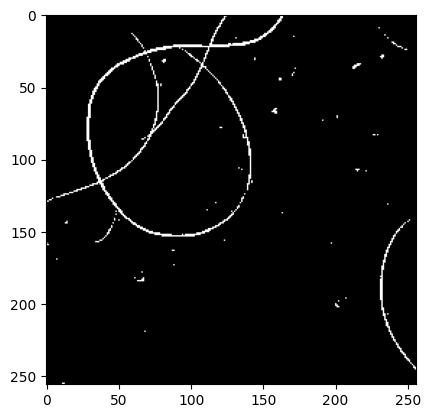

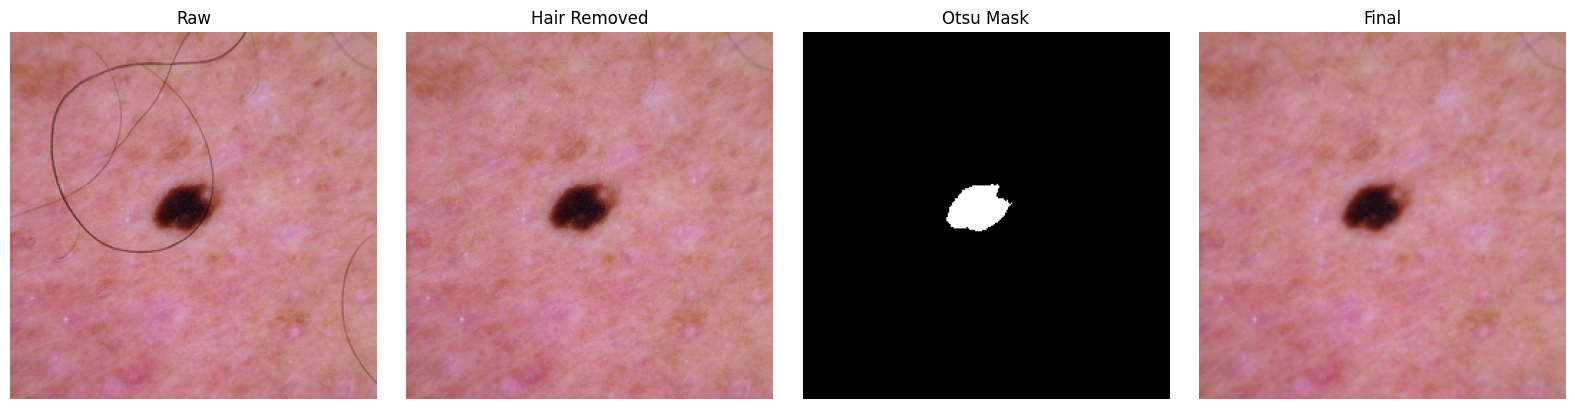

In [10]:
# quick visual sanity check on one sample
sample_path = train_df.iloc[0]["path"]

# Raw image
raw_bgr = cv2.imread(sample_path)
raw = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)

# Hair removal (nếu muốn xem riêng)
hair_removed = remove_hair_dullrazor(raw_bgr.copy())
hair_removed_rgb = cv2.cvtColor(hair_removed, cv2.COLOR_BGR2RGB)

# Otsu mask
mask = otsu_mask(hair_removed)

# Final preprocessing
proc = (preprocess_image(sample_path) * 255).astype(np.uint8)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].imshow(raw)
ax[0].set_title("Raw")
ax[0].axis("off")

ax[1].imshow(hair_removed_rgb)
ax[1].set_title("Hair Removed")
ax[1].axis("off")

ax[2].imshow(mask, cmap="gray")
ax[2].set_title("Otsu Mask")
ax[2].axis("off")

ax[3].imshow(proc)
ax[3].set_title("Final")
ax[3].axis("off")

plt.tight_layout()
plt.show()

## 3. Class balancing for training (Table 2: cap 3,500/class, augment minority classes)

In [11]:
# ==================== CONDITIONAL DCGAN CHO CÁC LỚP THIẾU ẢNH ====================
GAN_IMG_SIZE = 64
NOISE_DIM = 100
GAN_EPOCHS = 150            # tuỳ chỉnh theo ngân sách còn lại
GAN_BATCH_SIZE = 64
GAN_CKPT_DIR = f"{OUTPUT_DIR}/gan_checkpoints"
os.makedirs(GAN_CKPT_DIR, exist_ok=True)

MINORITY_LABELS = [l for l in range(len(CLASS_NAMES))
                    if (train_df["label"] == l).sum() < MAX_PER_CLASS]
print("Các lớp thiếu ảnh (sẽ dùng GAN):",
      [(CLASS_NAMES[l], int((train_df["label"] == l).sum())) for l in MINORITY_LABELS])

N_GAN_CLASSES = len(MINORITY_LABELS)
LABEL_TO_GANIDX = {l: i for i, l in enumerate(MINORITY_LABELS)}  # nén label gốc -> chỉ số 0..N_GAN_CLASSES-1

def build_generator():
    noise_in = layers.Input(shape=(NOISE_DIM,))
    label_in = layers.Input(shape=(1,), dtype="int32")
    label_emb = layers.Embedding(N_GAN_CLASSES, 50)(label_in)
    label_emb = layers.Flatten()(label_emb)
    x = layers.Concatenate()([noise_in, label_emb])
    x = layers.Dense(8 * 8 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((8, 8, 256))(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)  # 16x16
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)   # 32x32
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(32, 4, strides=2, padding="same", use_bias=False)(x)   # 64x64
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    out = layers.Conv2D(3, 5, padding="same", activation="tanh")(x)
    return models.Model([noise_in, label_in], out, name="cgan_generator")

def build_discriminator():
    img_in = layers.Input(shape=(GAN_IMG_SIZE, GAN_IMG_SIZE, 3))
    label_in = layers.Input(shape=(1,), dtype="int32")
    label_emb = layers.Embedding(N_GAN_CLASSES, GAN_IMG_SIZE * GAN_IMG_SIZE)(label_in)
    label_emb = layers.Reshape((GAN_IMG_SIZE, GAN_IMG_SIZE, 1))(label_emb)
    x = layers.Concatenate()([img_in, label_emb])
    x = layers.Conv2D(64, 4, strides=2, padding="same")(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(128, 4, strides=2, padding="same")(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(256, 4, strides=2, padding="same")(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1)(x)  # logits
    return models.Model([img_in, label_in], out, name="cgan_discriminator")

generator = build_generator()
discriminator = build_discriminator()

gen_opt = optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = optimizers.Adam(2e-4, beta_1=0.5)
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# ---- dataset: chỉ ảnh minority classes trong TRAIN, resize nhỏ 64x64, scale về [-1,1] ----
minority_train_df = train_df[train_df["label"].isin(MINORITY_LABELS)].reset_index(drop=True)

def _load_gan_img(path, label):
    def _py(p, l):
        img = cv2.imread(p.numpy().decode("utf-8"))
        img = cv2.resize(img, (GAN_IMG_SIZE, GAN_IMG_SIZE), interpolation=cv2.INTER_AREA)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img = (img / 127.5) - 1.0
        gan_idx = LABEL_TO_GANIDX[int(l.numpy())]
        return img, np.int32(gan_idx)
    img, gan_idx = tf.py_function(_py, [path, label], [tf.float32, tf.int32])
    img.set_shape([GAN_IMG_SIZE, GAN_IMG_SIZE, 3])
    gan_idx.set_shape([])
    return img, gan_idx

gan_ds = tf.data.Dataset.from_tensor_slices(
    (minority_train_df["path"].tolist(), minority_train_df["label"].tolist())
)
gan_ds = gan_ds.map(_load_gan_img, num_parallel_calls=tf.data.AUTOTUNE)
gan_ds = gan_ds.shuffle(2048, seed=SEED).batch(GAN_BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

@tf.function
def gan_train_step(real_imgs, gan_labels):
    bs = tf.shape(real_imgs)[0]
    noise = tf.random.normal([bs, NOISE_DIM])
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake_imgs = generator([noise, gan_labels], training=True)
        real_logits = discriminator([real_imgs, gan_labels], training=True)
        fake_logits = discriminator([fake_imgs, gan_labels], training=True)
        d_loss = bce(tf.ones_like(real_logits), real_logits) + bce(tf.zeros_like(fake_logits), fake_logits)
        g_loss = bce(tf.ones_like(fake_logits), fake_logits)
    d_grads = dt.gradient(d_loss, discriminator.trainable_variables)
    g_grads = gt.gradient(g_loss, generator.trainable_variables)
    disc_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))
    gen_opt.apply_gradients(zip(g_grads, generator.trainable_variables))
    return d_loss, g_loss

# ---- checkpoint: resume qua nhiều session ----
gan_epoch_var = tf.Variable(0, dtype=tf.int64)
gan_ckpt = tf.train.Checkpoint(generator=generator, discriminator=discriminator,
                                gen_opt=gen_opt, disc_opt=disc_opt, epoch=gan_epoch_var)
gan_ckpt_mgr = tf.train.CheckpointManager(gan_ckpt, GAN_CKPT_DIR, max_to_keep=2)
if gan_ckpt_mgr.latest_checkpoint:
    gan_ckpt.restore(gan_ckpt_mgr.latest_checkpoint)
    print(f"Resume GAN từ epoch {int(gan_epoch_var.numpy())}")

start_epoch = int(gan_epoch_var.numpy())
for epoch in range(start_epoch, GAN_EPOCHS):
    d_losses, g_losses = [], []
    for real_imgs, gan_labels in gan_ds:
        d_l, g_l = gan_train_step(real_imgs, gan_labels)
        d_losses.append(float(d_l)); g_losses.append(float(g_l))
    gan_epoch_var.assign(epoch + 1)
    if epoch % 5 == 0 or epoch == GAN_EPOCHS - 1:
        gan_ckpt_mgr.save()
        print(f"[GAN] epoch {epoch+1}/{GAN_EPOCHS}  d_loss={np.mean(d_losses):.3f}  g_loss={np.mean(g_losses):.3f}")

gan_ckpt_mgr.save()
print("GAN training xong / đã lưu checkpoint.")


Các lớp thiếu ảnh (sẽ dùng GAN): [('mel', 775), ('bkl', 774), ('bcc', 361), ('akiec', 228), ('vasc', 100), ('df', 76)]


I0000 00:00:1784056096.301136    2409 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784056096.304806    2409 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Resume GAN từ epoch 150
GAN training xong / đã lưu checkpoint.


In [12]:
# ==================== GENERATE ẢNH GAN CHO ĐẾN KHI ĐỦ 3500/LỚP ====================
GAN_FRACTION = 0.5   # tỉ lệ phần thiếu hụt được bù bằng GAN; phần còn lại bù bằng rotate/flip (mục 3b)
GAN_SYNTH_DIR = f"{OUTPUT_DIR}/gan_synthetic"
os.makedirs(GAN_SYNTH_DIR, exist_ok=True)

def denorm_and_upscale(img_batch):
    imgs = ((img_batch.numpy() + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    out = np.zeros((len(imgs), IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.uint8)
    for i, im in enumerate(imgs):
        out[i] = cv2.resize(im, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_CUBIC)
    return out

synthetic_rows = []  # (path, label)

for label in MINORITY_LABELS:
    n_real = int((train_df["label"] == label).sum())
    deficit = MAX_PER_CLASS - n_real
    n_gan_needed = int(round(deficit * GAN_FRACTION))
    class_dir = f"{GAN_SYNTH_DIR}/{CLASS_NAMES[label]}"
    os.makedirs(class_dir, exist_ok=True)

    existing = sorted(os.listdir(class_dir))
    n_existing = len(existing)
    for i, fname in enumerate(existing[:n_gan_needed]):
        synthetic_rows.append((os.path.join(class_dir, fname), label))

    n_to_generate = max(0, n_gan_needed - n_existing)
    if n_to_generate == 0:
        print(f"{CLASS_NAMES[label]}: đã có đủ {n_gan_needed} ảnh GAN, bỏ qua generate.")
        continue

    print(f"{CLASS_NAMES[label]}: sinh thêm {n_to_generate} ảnh GAN (đã có {n_existing}/{n_gan_needed})...")
    gan_idx = LABEL_TO_GANIDX[label]
    remaining = n_to_generate
    idx_offset = n_existing
    while remaining > 0:
        bs = min(GAN_BATCH_SIZE, remaining)
        noise = tf.random.normal([bs, NOISE_DIM])
        labels_in = tf.constant([[gan_idx]] * bs, dtype=tf.int32)
        fake_imgs = generator([noise, labels_in], training=False)
        upscaled = denorm_and_upscale(fake_imgs)
        for k in range(bs):
            fname = f"gan_{idx_offset + k:05d}.jpg"
            fpath = os.path.join(class_dir, fname)
            cv2.imwrite(fpath, cv2.cvtColor(upscaled[k], cv2.COLOR_RGB2BGR))
            synthetic_rows.append((fpath, label))
        idx_offset += bs
        remaining -= bs

synthetic_df = pd.DataFrame(synthetic_rows, columns=["path", "label"])
print("Tổng ảnh GAN synthetic dùng cho train:", len(synthetic_df))

# ---- metadata cho ảnh synthetic: không có bệnh nhân thật đứng sau ----
# -> mượn metadata (age/sex/localization) từ 1 ảnh THẬT ngẫu nhiên cùng lớp, để META_LOOKUP tra được
rng_meta = np.random.default_rng(SEED)
for path, label in synthetic_rows:
    same_class_paths = train_df.loc[train_df["label"] == label, "path"]
    donor_path = same_class_paths.sample(n=1, random_state=int(rng_meta.integers(0, 1_000_000))).iloc[0]
    META_LOOKUP[path] = META_LOOKUP[donor_path]


mel: đã có đủ 1362 ảnh GAN, bỏ qua generate.
bkl: đã có đủ 1363 ảnh GAN, bỏ qua generate.
bcc: đã có đủ 1570 ảnh GAN, bỏ qua generate.
akiec: đã có đủ 1636 ảnh GAN, bỏ qua generate.
vasc: đã có đủ 1700 ảnh GAN, bỏ qua generate.
df: đã có đủ 1712 ảnh GAN, bỏ qua generate.
Tổng ảnh GAN synthetic dùng cho train: 9343


In [13]:
# ==================== 3b. AUGMENTER (rotate/flip) + BALANCED INDEX (real + rotate/flip + GAN) ====================
AUGMENTER = tf.keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
])


def build_balanced_training_index(df, synthetic_df, max_per_class=MAX_PER_CLASS, seed=SEED):
    """Với mỗi lớp:
    - >= max_per_class ảnh thật: undersample về đúng max_per_class (aug_flag=False)
    - < max_per_class ảnh thật: giữ TOÀN BỘ ảnh gốc (aug_flag=False)
                                 + ảnh GAN synthetic đã sinh sẵn (aug_flag=False — không rotate/flip
                                   thêm lên ảnh đã là output của generator, tránh chồng méo 2 lần)
                                 + phần thiếu còn lại bù bằng duplicate ảnh thật + rotate/flip (aug_flag=True)
    """
    rng = np.random.default_rng(seed)
    entries = []

    for label_idx in range(len(CLASS_NAMES)):
        pos = np.where(df["label"].to_numpy() == label_idx)[0]
        n = len(pos)

        if n >= max_per_class:
            chosen = rng.choice(pos, size=max_per_class, replace=False)
            for p in chosen:
                entries.append((df["path"].iloc[p], label_idx, True))
            continue

        # 1) toàn bộ ảnh gốc thật
        for p in pos:
            entries.append((df["path"].iloc[p], label_idx, True))
        filled = n

        # 2) ảnh GAN synthetic (đã sinh ở cell 3a) cho đúng lớp này
        synth_paths = synthetic_df.loc[synthetic_df["label"] == label_idx, "path"].tolist()
        need = max_per_class - filled
        take_synth = synth_paths[:need]
        for sp in take_synth:
            entries.append((sp, label_idx, False))
        filled += len(take_synth)

        # 3) phần còn thiếu: duplicate ảnh thật + rotate/flip lúc train
        remaining = max_per_class - filled
        if remaining > 0:
            extra = rng.choice(pos, size=remaining, replace=True)
            for p in extra:
                entries.append((df["path"].iloc[p], label_idx, True))

    rng.shuffle(entries)
    return entries


train_entries = build_balanced_training_index(train_df, synthetic_df)

print("Balanced train size:", len(train_entries))
for label_idx in range(len(CLASS_NAMES)):
    n_real = (train_df["label"] == label_idx).sum()
    n_synth = sum(1 for p, l, a in train_entries if l == label_idx and p in set(synthetic_df["path"]))
    n_total = sum(1 for p, l, a in train_entries if l == label_idx)
    print(f"{CLASS_NAMES[label_idx]:6s}: thật={n_real:5d}  GAN={n_synth:5d}  tổng={n_total:5d}")


Balanced train size: 24500
nv    : thật= 3500  GAN=    0  tổng= 3500
mel   : thật=  775  GAN= 1362  tổng= 3500
bkl   : thật=  774  GAN= 1363  tổng= 3500
bcc   : thật=  361  GAN= 1570  tổng= 3500
akiec : thật=  228  GAN= 1636  tổng= 3500
vasc  : thật=  100  GAN= 1700  tổng= 3500
df    : thật=   76  GAN= 1712  tổng= 3500


In [14]:
def make_dataset(
    entries_or_df,
    training,
    batch_size=BATCH_SIZE,
    is_df=False
):

    if is_df:

        paths = entries_or_df["path"].tolist()
        labels = entries_or_df["label"].tolist()
        aug_flags = [False] * len(paths)

    else:

        paths = [e[0] for e in entries_or_df]
        labels = [e[1] for e in entries_or_df]
        aug_flags = [e[2] for e in entries_or_df]

    ds = tf.data.Dataset.from_tensor_slices(
        (
            paths,
            labels,
            aug_flags
        )
    )

    def _load(path, label, aug_flag):

        def _py_load(p):
            p_str = p.numpy().decode("utf-8")
            img = preprocess_image(p_str)
            meta_vec = META_LOOKUP[p_str]  # metadata (age, sex, localization) đi kèm ảnh
            return img, meta_vec

        img, meta_vec = tf.py_function(
            _py_load,
            [path],
            [tf.float32, tf.float32]
        )

        img.set_shape(
            [
                IMG_HEIGHT,
                IMG_WIDTH,
                3
            ]
        )
        meta_vec.set_shape([META_DIM])

        return (img, meta_vec, aug_flag), tf.one_hot(
            label,
            depth=len(CLASS_NAMES)
        )

    ds = ds.map(
        _load,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:

        ds = ds.shuffle(
            2048,
            seed=SEED
        )

        def apply_aug(x, y):

            img, meta_vec, aug_flag = x

            img = tf.cond(
                aug_flag,
                lambda: AUGMENTER(
                    img,
                    training=True
                ),
                lambda: img
            )

            return (img, meta_vec), y

        ds = ds.map(
            apply_aug,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    else:

        ds = ds.map(
            lambda x, y: ((x[0], x[1]), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [15]:
train_ds = make_dataset(
    train_entries,
    training=True
)

val_ds = make_dataset(
    val_df,
    training=False,
    is_df=True
)

test_ds = make_dataset(
    test_df,
    training=False,
    is_df=True
)

In [16]:
train_df.to_csv(f"{OUTPUT_DIR}/train_split.csv", index=False)
val_df.to_csv(f"{OUTPUT_DIR}/val_split.csv", index=False)
test_df.to_csv(f"{OUTPUT_DIR}/test_split.csv", index=False)

print("Saved train/val/test splits.")

Saved train/val/test splits.


In [17]:
train_df = pd.read_csv(f"{OUTPUT_DIR}/train_split.csv")
val_df   = pd.read_csv(f"{OUTPUT_DIR}/val_split.csv")
test_df  = pd.read_csv(f"{OUTPUT_DIR}/test_split.csv")


## 4. Model definitions — Technique 2 (fine-tune back half of backbone + custom head)

Following the **prose** description in Section 3.4/3.5 (not Figures 6/7 — see deviation note in cell 1):
freeze the first half of the backbone's layers, unfreeze the back half, append
`GlobalAveragePooling2D → Dense(512, relu) → Dropout(0.5) → Dense(7, softmax)`.


In [18]:
def build_finetuned_model(backbone_fn, name):
    backbone = backbone_fn(weights="imagenet", include_top=False,
                            input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    n_layers = len(backbone.layers)
    # Giảm phần unfreeze: chỉ mở khóa ~20-25% cuối thay vì 50%
    freeze_until = int(n_layers * 0.80)
    for i, layer in enumerate(backbone.layers):
        # Luôn giữ BatchNorm đóng băng dù nằm trong phần "unfreeze"
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = i >= freeze_until

    img_feat = backbone.output
    img_feat = layers.GlobalAveragePooling2D()(img_feat)
    img_feat = layers.Dropout(0.3)(img_feat)  # thêm dropout ngay sau backbone

    meta_input = layers.Input(shape=(META_DIM,), name="metadata_input")
    meta_feat = layers.Dense(64, activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(meta_input)
    meta_feat = layers.Dropout(0.3)(meta_feat)
    meta_feat = layers.Dense(32, activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(meta_feat)

    x = layers.Concatenate()([img_feat, meta_feat])
    x = layers.Dense(512, activation="relu",
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(7, activation="softmax")(x)
    return models.Model([backbone.input, meta_input], out, name=name)

def compile_model(model):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [30]:

def get_callbacks(model_name, use_wandb=True):
    backup_dir = f"{OUTPUT_DIR}/backup_{model_name}"
    cbs = [
        
        callbacks.BackupAndRestore(backup_dir=backup_dir),  # resume training state after disconnect
        callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(filepath=f"{OUTPUT_DIR}/{model_name}.keras", monitor="val_loss", mode="min", save_best_only=True, verbose=1),
    
        callbacks.CSVLogger(f"{OUTPUT_DIR}/{model_name}_history.csv", append=True),  # append=True: don't clobber rows already logged before disconnect
        callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=3,min_lr=1e-7,verbose=1)
    ]
    
    if use_wandb:
        cbs.append(WandbMetricsLogger(log_freq="epoch"))
        
    return cbs

def _run_id_path(model_name):
    return f"{OUTPUT_DIR}/{model_name}_wandb_run_id.txt"

def get_or_create_run_id(model_name):
    p = _run_id_path(model_name)
    if os.path.exists(p):
        return open(p).read().strip()
    return None

def save_run_id(model_name, run_id):
    with open(_run_id_path(model_name), "w") as f:
        f.write(run_id)

def train_model(backbone_fn, keras_module_name, model_name, use_wandb=True):
    if use_wandb:
        run_id = get_or_create_run_id(model_name)
        run = wandb.init(
            project=WANDB_PROJECT, entity=WANDB_ENTITY, name=model_name,
            id=run_id, resume="allow",   # thay cho reinit='finish_previous'
            config=dict(
                backbone=keras_module_name, technique="technique2_unfreeze_back_half",
                img_height=IMG_HEIGHT, img_width=IMG_WIDTH, batch_size=BATCH_SIZE,
                max_epochs=MAX_EPOCHS, early_stop_patience=EARLY_STOP_PATIENCE,
                learning_rate=LEARNING_RATE, max_per_class=MAX_PER_CLASS, seed=SEED,
                apply_segmentation_mask=APPLY_SEGMENTATION_MASK,
            ),
        )
        save_run_id(model_name, run.id)
    model = build_finetuned_model(backbone_fn, model_name)
    compile_model(model)
    print(model.summary())
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=MAX_EPOCHS, callbacks=get_callbacks(model_name, use_wandb=use_wandb),
    )
    if use_wandb:
        wandb.finish()
    return model, history





## 5. Train DenseNet201

In [20]:
from tensorflow.keras.applications import DenseNet201
import os

probs_path = f"{OUTPUT_DIR}/densenet201_test_probs.npy"

if os.path.exists(probs_path):
    print(" DenseNet201 đã train xong (tìm thấy test_probs.npy), bỏ qua training.")
    densenet_model = tf.keras.models.load_model(f"{OUTPUT_DIR}/densenet201_finetuned.keras")
    # Load history nếu cần
    densenet_hist = pd.read_csv(f"{OUTPUT_DIR}/densenet201_history.csv")
else:
    print(" Bắt đầu train DenseNet201...")
    densenet_model, densenet_hist = train_model(DenseNet201, "densenet201", "densenet201_finetuned")
    
    # Cell lưu probs sẽ chạy tiếp bình thường

 Bắt đầu train DenseNet201...


Model: "densenet201_finetuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 19,328,871 (73.73 MB)

 Trainable params: 5,799,207 (22.12 MB)

...

epoch/accuracy,▁▂▃▅▆▄█
epoch/epoch,▁▂▃▅▆▇█
epoch/learning_rate,███▃▃▃▁
epoch/loss,█▇▆▄▂▃▁
epoch/val_accuracy,▇▃▅▅▁█▃
epoch/val_loss,▁█▆▆▆▃▃
epoch/accuracy,0.80065
epoch/epoch,28
epoch/learning_rate,0.0
epoch/loss,0.56813
epoch/val_accuracy,0.75226


Error in callback <function _draw_all_if_interactive at 0x7a8d6f3c0a40> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7a8d6f396340> (for post_execute):


KeyboardInterrupt: 

In [24]:
# Sau khi interrupt, chạy cell riêng để nạp lại model/hist từ file đã lưu
densenet_model = tf.keras.models.load_model(f"{OUTPUT_DIR}/densenet201_finetuned.keras")
densenet_hist = pd.read_csv(f"{OUTPUT_DIR}/densenet201_finetuned_history.csv")  # thêm "_finetuned"

In [27]:
import gc
import numpy as np

prob_path = f"{OUTPUT_DIR}/densenet201_test_probs.npy"

if os.path.exists(prob_path):
    probs_dense = np.load(prob_path)
else:
    probs_dense = densenet_model.predict(test_ds)
    np.save(prob_path, probs_dense)

labels_path = f"{OUTPUT_DIR}/test_labels.npy"
if not os.path.exists(labels_path):
    labels = np.concatenate([y.numpy() for _, y in test_ds])
    np.save(labels_path, labels)
try:
    wandb.finish()
except Exception as e:
    print("wandb.finish() lỗi:", e)

del densenet_model
del densenet_hist
del probs_dense
tf.keras.backend.clear_session()
gc.collect()

32/32 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step 


0

## 6. Train InceptionV3

In [31]:
from tensorflow.keras.applications import InceptionV3

probs_path = f"{OUTPUT_DIR}/inceptionv3_test_probs.npy"

if os.path.exists(probs_path):
    print("InceptionV3 đã train xong, bỏ qua.")
    inception_model = tf.keras.models.load_model(f"{OUTPUT_DIR}/inceptionv3_finetuned.keras")
    
    inception_hist = pd.read_csv(f"{OUTPUT_DIR}/inceptionv3_finetuned_history.csv")
else:
    print(" Bắt đầu train InceptionV3...")
    inception_model, inception_hist = train_model(InceptionV3, "inceptionv3", "inceptionv3_finetuned")

 Bắt đầu train InceptionV3...


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "inceptionv3_finetuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,875,207 (87.26 MB)

 Trainable params: 12,180,775 (46.47 MB)

 Non-trainable params: 10,694,432 (40.80 MB)

None
Epoch 1/40
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.2795 - loss: 1.9128
Epoch 1: val_loss improved from None to 1.00223, saving model to /kaggle/working/outputs/inceptionv3_finetuned.keras

Epoch 1: finished saving model to /kaggle/working/outputs/inceptionv3_finetuned.keras
383/383 ━━━━━━━━━━━━━━━━━━━━ 320s 732ms/step - accuracy: 0.3698 - loss: 1.6868 - val_accuracy: 0.6830 - val_loss: 1.0022 - learning_rate: 1.0000e-05
Epoch 2/40
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.5223 - loss: 1.3142
Epoch 2: val_loss improved from 1.00223 to 0.93416, saving model to /kaggle/working/outputs/inceptionv3_finetuned.keras

Epoch 2: finished saving model to /kaggle/working/outputs/inceptionv3_finetuned.keras
383/383 ━━━━━━━━━━━━━━━━━━━━ 261s 651ms/step - accuracy: 0.5402 - loss: 1.2580 - val_accuracy: 0.6861 - val_loss: 0.9342 - learning_rate: 1.0000e-05
Epoch 3/40
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.5850 - loss: 1.1325
Epoch 3: val_loss impr

epoch/accuracy,▁▄▅▅▆▆▇▇▇███
epoch/epoch,▁▂▂▃▄▄▅▅▆▇▇█
epoch/learning_rate,████████▃▃▃▁
epoch/loss,█▅▄▄▃▃▂▂▂▁▁▁
epoch/val_accuracy,▁▂▄▁▄▅▇▆▅▅▆█
epoch/val_loss,█▄▂▅▂▁▂▁▂▄▃▂
epoch/accuracy,0.82837
epoch/epoch,11
epoch/learning_rate,0.0
epoch/loss,0.54484
epoch/val_accuracy,0.7322


In [32]:
prob_path = f"{OUTPUT_DIR}/inceptionv3_test_probs.npy"

if not os.path.exists(prob_path):
    probs_inception = inception_model.predict(test_ds)
    np.save(prob_path, probs_inception)


try:
    wandb.finish()
except Exception as e:
    print("wandb.finish() lỗi:", e)

del inception_model
del inception_hist

if "probs_inception" in locals():
    del probs_inception

if "labels" in locals():
    del labels

tf.keras.backend.clear_session()
gc.collect()

32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 826ms/step


0

## 7. Train VGG16

In [35]:
from tensorflow.keras.applications import VGG16

probs_path = f"{OUTPUT_DIR}/vgg16_test_probs.npy"

if os.path.exists(probs_path):
    print(" vgg16 đã train xong, bỏ qua.")
    vgg16_model = tf.keras.models.load_model(f"{OUTPUT_DIR}/vgg16_finetuned.keras")
    vgg16_hist = pd.read_csv(f"{OUTPUT_DIR}/vgg16_finetuned_history.csv")
else:
    print(" Bắt đầu train VGG16...")
    vgg16_model, vgg16_hist = train_model(VGG16, "vgg16", "vgg16_finetuned")

 Bắt đầu train VGG16...


Model: "vgg16_finetuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 15,000,679 (57.22 MB)

 Trainable params: 7,365,415 (28.10 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

None
Epoch 1/40
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.1994 - loss: 2.0430
Epoch 1: val_loss improved from None to 1.27964, saving model to /kaggle/working/outputs/vgg16_finetuned.keras

Epoch 1: finished saving model to /kaggle/working/outputs/vgg16_finetuned.keras
383/383 ━━━━━━━━━━━━━━━━━━━━ 345s 850ms/step - accuracy: 0.2739 - loss: 1.8614 - val_accuracy: 0.6299 - val_loss: 1.2796 - learning_rate: 1.0000e-05
Epoch 2/40
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.4332 - loss: 1.4781
Epoch 2: val_loss improved from 1.27964 to 1.09074, saving model to /kaggle/working/outputs/vgg16_finetuned.keras

Epoch 2: finished saving model to /kaggle/working/outputs/vgg16_finetuned.keras
383/383 ━━━━━━━━━━━━━━━━━━━━ 334s 841ms/step - accuracy: 0.4582 - loss: 1.4167 - val_accuracy: 0.6389 - val_loss: 1.0907 - learning_rate: 1.0000e-05
Epoch 3/40
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.5039 - loss: 1.2915
Epoch 3: val_loss improved from 1.09074 to 0.9

epoch/accuracy,▁▄▄▅▅▆▆▆▆▇▇▇▇▇▇███████
epoch/epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
epoch/learning_rate,██████████████████▃▃▃▁
epoch/loss,█▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
epoch/val_accuracy,▁▂▃▄▄▅▃▄▄▂▅▆▅▅▅█▆▇▅▆▅▇
epoch/val_loss,█▆▄▄▄▃▄▃▃▄▃▂▂▂▂▁▂▂▂▂▂▂
epoch/accuracy,0.77988
epoch/epoch,21
epoch/learning_rate,0.0
epoch/loss,0.61896
epoch/val_accuracy,0.71615


In [36]:

prob_path = f"{OUTPUT_DIR}/vgg16_test_probs.npy"

# Chỉ predict nếu chưa có file
if not os.path.exists(prob_path):
    print("Generating VGG16 predictions...")
    probs_vgg16 = vgg16_model.predict(test_ds, verbose=1)
    np.save(prob_path, probs_vgg16)
    print(f"Saved predictions to {prob_path}")
else:
    print("Predictions already exist. Skipping prediction.")

try:
    wandb.finish()
except Exception as e:
    print("wandb.finish() lỗi:", e)


del vgg16_model
del vgg16_hist

if "probs_vgg16" in locals():
    del probs_vgg16

if "labels" in locals():
    del labels

tf.keras.backend.clear_session()
gc.collect()


Generating VGG16 predictions...
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step 
Saved predictions to /kaggle/working/outputs/vgg16_test_probs.npy


0

## 8. Training curves

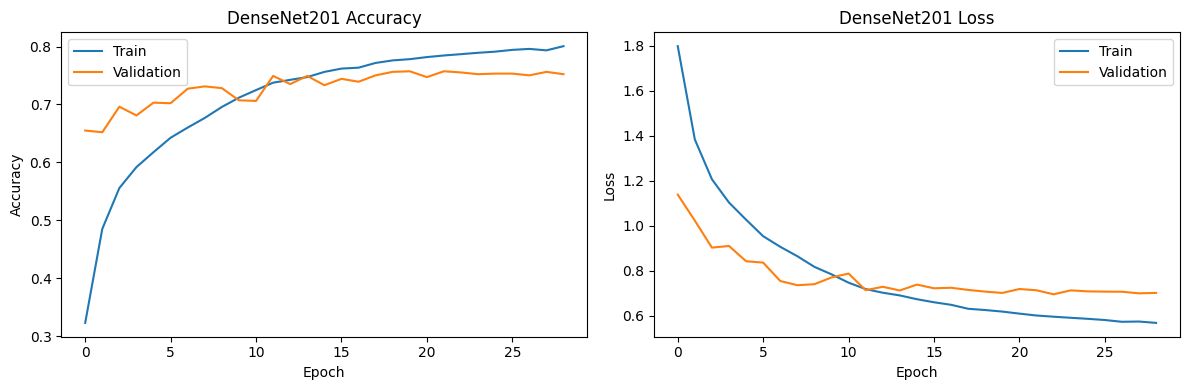

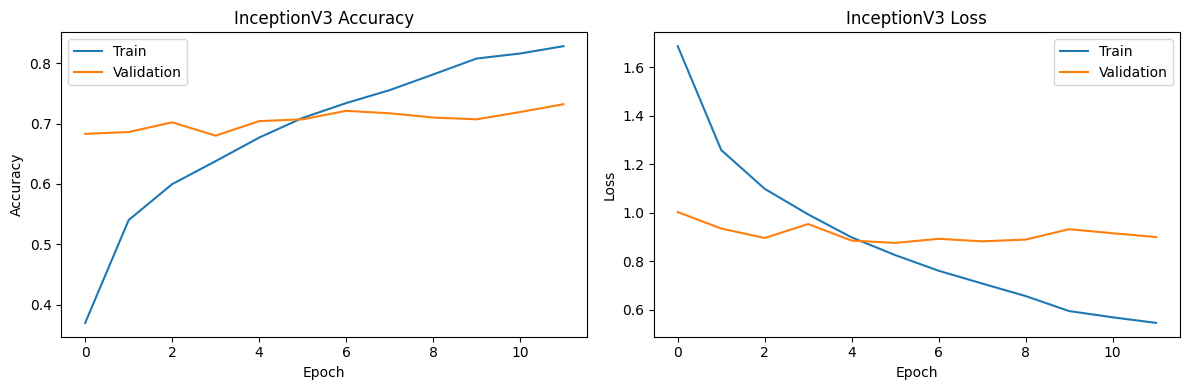

 VGG16: phát hiện 22 epoch bị lặp trong /kaggle/working/outputs/vgg16_finetuned_history.csv — đã lọc, giữ bản ghi cuối cùng.


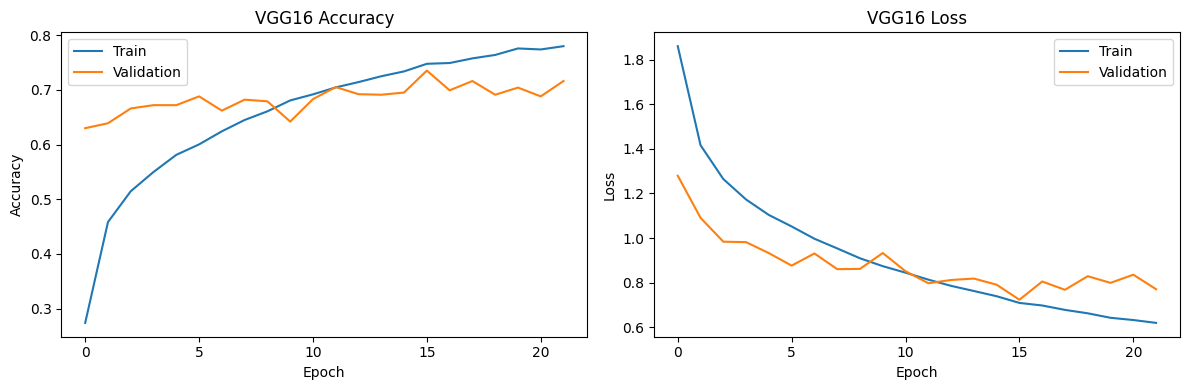

In [37]:
def plot_history(csv_path, name):
    hist = pd.read_csv(csv_path)

    # Guard: CSVLogger(append=True) có thể ghi lặp epoch nếu training bị restart
    # giữa chừng (trước khi kịp lưu probs.npy). Loại bỏ dòng epoch trùng, giữ lần cuối.
    if "epoch" in hist.columns:
        dup_count = hist["epoch"].duplicated().sum()
        if dup_count > 0:
            print(f" {name}: phát hiện {dup_count} epoch bị lặp trong {csv_path} — đã lọc, giữ bản ghi cuối cùng.")
            hist = hist.drop_duplicates(subset="epoch", keep="last").reset_index(drop=True)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    ax[0].plot(hist["accuracy"], label="Train")
    ax[0].plot(hist["val_accuracy"], label="Validation")
    ax[0].set_title(f"{name} Accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()

    # Loss
    ax[1].plot(hist["loss"], label="Train")
    ax[1].plot(hist["val_loss"], label="Validation")
    ax[1].set_title(f"{name} Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend()

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{name}_training_curve.png", dpi=300)
    plt.show()


# ==================== GỌI THỰC TẾ — bắt buộc để có hình xuất ra ====================
_curve_configs = [
    (f"{OUTPUT_DIR}/densenet201_finetuned_history.csv", "DenseNet201"),
    (f"{OUTPUT_DIR}/inceptionv3_finetuned_history.csv", "InceptionV3"),
    (f"{OUTPUT_DIR}/vgg16_finetuned_history.csv", "VGG16"),
]

for csv_path, name in _curve_configs:
    if os.path.exists(csv_path):
        plot_history(csv_path, name)
    else:
        print(f" Không tìm thấy {csv_path} — {name} có thể chưa train xong hoặc đường dẫn sai.")

## 9. Soft-voting ensemble (Section 3.4) + evaluation on held-out lesion-wise test set

In [38]:
# ==================== LOAD SAVED PREDICTIONS ====================

p_dense = np.load(f"{OUTPUT_DIR}/densenet201_test_probs.npy")
p_incep = np.load(f"{OUTPUT_DIR}/inceptionv3_test_probs.npy")
p_vgg   = np.load(f"{OUTPUT_DIR}/vgg16_test_probs.npy")

# labels đã lưu trước đó
y_true_oh = np.load(f"{OUTPUT_DIR}/test_labels.npy")
y_true = np.argmax(y_true_oh, axis=1)

# ==================== SOFT VOTING ====================

ensemble_probs = (p_dense + p_incep + p_vgg) / 3.0
y_pred_ensemble = np.argmax(ensemble_probs, axis=1)

# ==================== REPORT ====================

def report(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    ))
    acc = (y_true == y_pred).mean()
    print(f"Overall accuracy: {acc:.4f}")
    return acc

# Từng model
for probs, name in [
    (p_dense, "DenseNet201"),
    (p_incep, "InceptionV3"),
    (p_vgg, "VGG16"),
]:
    report(y_true, np.argmax(probs, axis=1), name)

# Ensemble
ensemble_acc = report(
    y_true,
    y_pred_ensemble,
    "Soft-Voting Ensemble"
)


=== DenseNet201 ===
              precision    recall  f1-score   support

          nv     0.9108    0.8590    0.8842      1355
         mel     0.4706    0.5195    0.4938       231
         bkl     0.5385    0.6278    0.5797       223
         bcc     0.5372    0.6436    0.5856       101
       akiec     0.5000    0.4648    0.4818        71
        vasc     0.7200    0.6429    0.6792        28
          df     0.2812    0.3214    0.3000        28

    accuracy                         0.7604      2037
   macro avg     0.5655    0.5827    0.5720      2037
weighted avg     0.7760    0.7604    0.7669      2037

Overall accuracy: 0.7604

=== InceptionV3 ===
              precision    recall  f1-score   support

          nv     0.9233    0.7911    0.8521      1355
         mel     0.3895    0.4502    0.4177       231
         bkl     0.4405    0.6637    0.5295       223
         bcc     0.6000    0.6238    0.6117       101
       akiec     0.4250    0.4789    0.4503        71
        vas

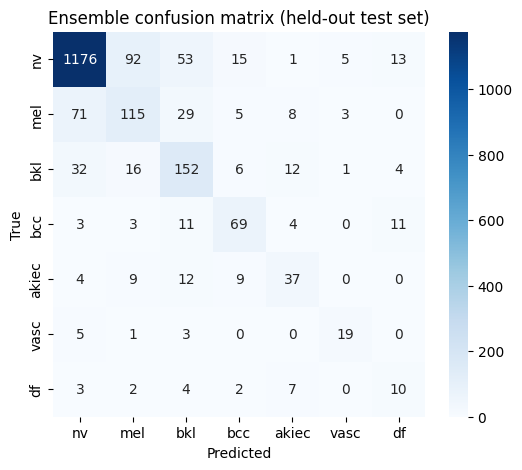

In [39]:

cm = confusion_matrix(y_true, y_pred_ensemble)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Ensemble confusion matrix (held-out test set)")
plt.show()


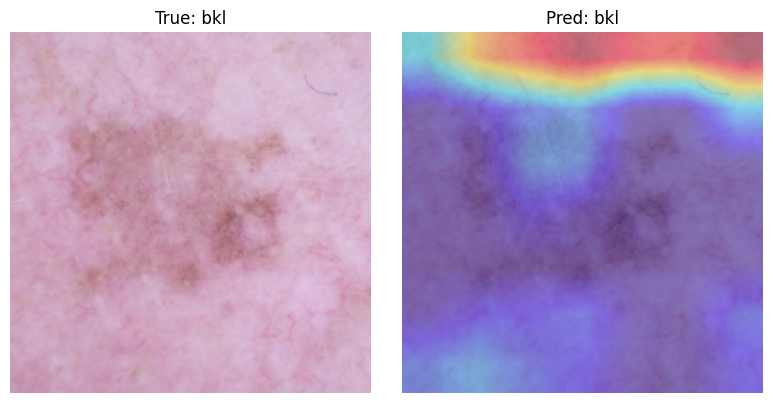

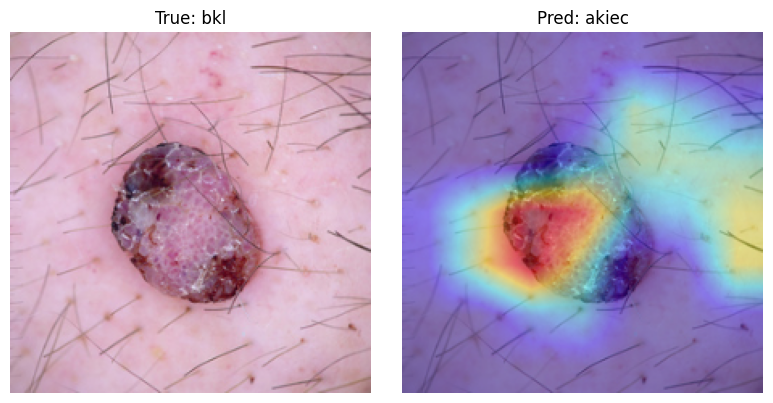

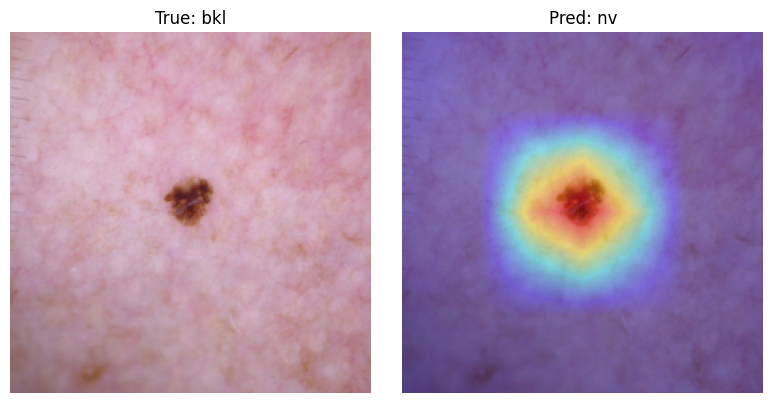

0

In [42]:
MODEL_NAME = "densenet201_finetuned"      # đổi thành inceptionv3_finetuned hoặc vgg16_finetuned nếu muốn

model = tf.keras.models.load_model(
    f"{OUTPUT_DIR}/{MODEL_NAME}.keras"
)

# ==================== LOAD PREDICTIONS ====================

probs = np.load(f"{OUTPUT_DIR}/densenet201_test_probs.npy")
y_true = np.argmax(np.load(f"{OUTPUT_DIR}/test_labels.npy"), axis=1)
y_pred = np.argmax(probs, axis=1)

# ==================== GRAD-CAM FUNCTIONS ====================

def find_gap_input(model):
    for layer in model.layers:
        if isinstance(layer, layers.GlobalAveragePooling2D):
            return layer.input
    raise ValueError("GlobalAveragePooling2D not found.")

def make_gradcam_model(model):
    conv_output = find_gap_input(model)
    return models.Model(
        inputs=model.input,
        outputs=[conv_output, model.output]
    )

def grad_cam(model, img_array, meta_array, class_idx=None):

    grad_model = make_gradcam_model(model)

    with tf.GradientTape() as tape:

        conv_out, preds = grad_model(
            [img_array, meta_array],
            training=False
        )

        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))

        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_out = conv_out[0]

    heatmap = conv_out @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0)

    heatmap /= tf.reduce_max(heatmap)+1e-8

    return heatmap.numpy(), class_idx

def overlay_gradcam(raw_img_rgb, heatmap, alpha=0.4):

    heatmap = cv2.resize(
        heatmap,
        (raw_img_rgb.shape[1], raw_img_rgb.shape[0])
    )

    heatmap = np.uint8(255*heatmap)

    colored = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    colored = cv2.cvtColor(
        colored,
        cv2.COLOR_BGR2RGB
    )

    return np.uint8(
        raw_img_rgb*(1-alpha)+colored*alpha
    )

# ==================== CHỌN 2 ĐÚNG + 1 SAI ====================

correct_idx = np.where(y_true == y_pred)[0]
wrong_idx = np.where(y_true != y_pred)[0]

selected = [
    ("Correct 1", correct_idx[0]),
    ("Correct 2", correct_idx[1]),
    ("Wrong", wrong_idx[0]),
]

# ==================== VẼ ====================

for title, idx in selected:

    sample_row = test_df.iloc[idx]

    img = preprocess_image(sample_row["path"])

    meta = encode_metadata_row(sample_row)

    heatmap, pred_class = grad_cam(
        model,
        img[np.newaxis,...],
        meta[np.newaxis,...]
    )

    raw = cv2.cvtColor(
        cv2.imread(sample_row["path"]),
        cv2.COLOR_BGR2RGB
    )

    raw = cv2.resize(
        raw,
        (IMG_WIDTH,IMG_HEIGHT)
    )

    overlay = overlay_gradcam(raw,heatmap)

    fig,ax = plt.subplots(
        1,
        2,
        figsize=(8,4)
    )

    ax[0].imshow(raw)
    ax[0].set_title(
        f"True: {CLASS_NAMES[sample_row['label']]}"
    )
    ax[0].axis("off")

    ax[1].imshow(overlay)
    ax[1].set_title(
        f"Pred: {CLASS_NAMES[pred_class]}"
    )
    ax[1].axis("off")

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{MODEL_NAME}_{title.replace(' ','_')}_gradcam.png",
        dpi=300
    )

    plt.show()

# ==================== FREE RAM ====================

del model

tf.keras.backend.clear_session()

gc.collect()

In [41]:
def specificity_per_class(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    specs = {}
    total = cm.sum()
    for i, cls in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        specs[cls] = tn / (tn + fp + 1e-8)
    return specs

specs = specificity_per_class(y_true, y_pred_ensemble, CLASS_NAMES)
for cls, s in specs.items():
    print(f"{cls:6s} specificity: {s:.4f}")

nv     specificity: 0.8270
mel    specificity: 0.9319
bkl    specificity: 0.9383
bcc    specificity: 0.9809
akiec  specificity: 0.9837
vasc   specificity: 0.9955
df     specificity: 0.9861
